# IMPLEMENTACIÓN FIGS ##
En este documento se implmenta la metodología FIGS. Para ello se estartifica las variables **eco-ambientales** usando 7 variables climáticas y topográficas no colineales.

Es importante el uso de K-means, en este caso **k=3** identificando tres ambientes que se contrasten. **Seco, Intermedio, Húmedo**.

* **Seco (Sequía):** precipitación anual y CMI bajos; aridez alta.
* **Intermedio y húmedo(anegamiento)** precipitación alta; aridez baja

## Importación de librerías ##

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier
import joblib   # para cargar el modelo guardado previamente
import shap

C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## FIGS: ESTARTIFICACIÓN ECO-AMBIENTAL CON K-MEANS ##

Para la implementación de la estrategia metodológica FIGS (Focus Identification of Germplasm Strategy), se utilizó un conjunto de datos que previamente depuré y ajusté a los requerimientos de la modelación eco-ambiental. esto implica la imputación de valores faltantes en las variables climáticas y edáficas mediante métodos de estimación estadística, garantizando la completitud de la matriz de datos.

Posteriormente, realicé la depuración espacial mediante la exclusión de accesiones con alta proximidad geográfica (“redundancia por vecindad”), esto con el fin de evitar sobre-representación de microambientes y mejorar la independencia espacial del muestreo.

Adicionalmente, se apliqué un análisis de multicolinealidad para eliminar variables altamente correlacionadas (|r| ≥ 0.9 o VIF > 5), conservando únicamente aquellas con aportes independientes a la variabilidad ecológica. Es necesario decir que aunque realicé VIF no uso el dataset obtendio ya que este proceso me excluye variables de forma matemática pero no tiene en cuenta las variables ecológicas.

## ***************************************************************************************************************


Promedios eco-ambientales por cluster FIGS:
               bio12  bio13  current_30arcsec_climaticMoistureIndex  \
FIGS_cluster                                                         
0             -0.36  -0.10                                   -0.74   
1             -0.60  -0.71                                    0.14   
2              0.90   0.64                                    0.87   

              current_30arcsec_aridityIndexThornthwaite  \
FIGS_cluster                                              
0                                                  0.75   
1                                                 -0.47   
2                                                 -0.64   

              current_30arcsec_annualPET  ELEVATION  DECLATITUDE  \
FIGS_cluster                                                       
0                                   0.68       0.45        12.16   
1                                  -1.16      -0.86        40.10   
2                                  

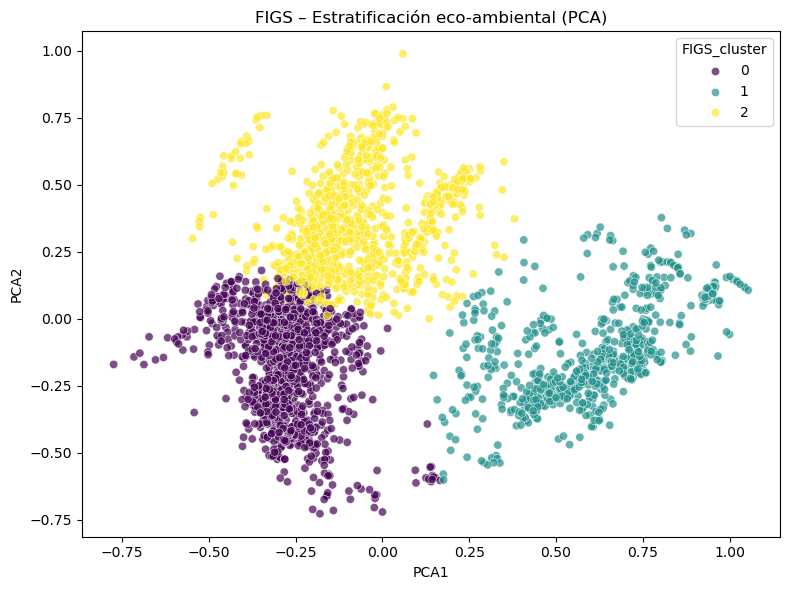


 Dataset guardado con FIGS_cluster en ./dataset_salida/dataset_con_figs.csv


In [2]:
#-------------------------------------------------------------------------------------------------------------------------------
# PREPARACIÓN DE LOS DATOS
#-------------------------------------------------------------------------------------------------------------------------------

## Cargando el dataset
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

# Variables ambientales para FIGS
# Estas variables representan temperatura, pecipitación, altimetría y aridez o humedad y representan el ambiente ecológico
vars_figs = [
    'bio12', 'bio13', 
    'current_30arcsec_climaticMoistureIndex',
    'current_30arcsec_aridityIndexThornthwaite',
    'current_30arcsec_annualPET',
    'ELEVATION', 'DECLATITUDE', 'DECLONGITUDE',
    'srad_1', 'srad_5', 'srad_10'
]

# Eliminar filas con datos faltantes (No debería tener porque parte de
df_figs = df.dropna(subset=vars_figs).copy()

# Normalizar variables: Se debe escalar las variables enrre 0 y 1, importante para k-means
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_figs[vars_figs])



#-------------------------------------------------------------------------------------------------------------------------------
# K-MEANS PARA CREAR GRUPOS ECO-AMBIENTALES
#-------------------------------------------------------------------------------------------------------------------------------

# Aplicar K-Means (k=3)
# n_clusters=3 -> tres grupos (seco, intermedio, húmedo)
# random_state=42 -> Se asegura reproducibilidad
# n_init=10 -> repite el proceso 10 veces y escoge la mejor partición
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_figs["FIGS_cluster"] = kmeans.fit_predict(X_scaled)



#-------------------------------------------------------------------------------------------------------------------------------
# CARACTERIZACIÓNDE LOS CLUSTERS
#-------------------------------------------------------------------------------------------------------------------------------

# Resumen de los cluster
# Calcula la media de cada variable dentro de cada cluster.
# Esto te permite caracterizar cada ambiente (por ejemplo, seco = baja precipitación, alta aridez).
summary = df_figs.groupby("FIGS_cluster")[vars_figs].mean().round(2)
print("\nPromedios eco-ambientales por cluster FIGS:\n", summary)



#-------------------------------------------------------------------------------------------------------------------------------
# VISUALIZACIÓN DE LOS CLUSTERS
#-------------------------------------------------------------------------------------------------------------------------------

# Visualizar con reducción de dos dimensiones(PCA 2D)
# PCA convierte las variables multidimensionales en dos ejes principales (PCA1 y PCA2)
# Lo anterior me permite poder graficarlas en 2D y visualizar la separación de los clusters.
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_figs["PCA1"], df_figs["PCA2"] = coords[:,0], coords[:,1]

# Creación del gráfico
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_figs, x="PCA1", y="PCA2", hue="FIGS_cluster", palette="viridis", alpha=0.7)
plt.title("FIGS – Estratificación eco-ambiental (PCA)")
plt.tight_layout()
plt.savefig("./graficas/figs_clusters_pca.png", dpi=200)
plt.show()


#-------------------------------------------------------------------------------------------------------------------------------
# GUARDANDO LOS RESULTADOS
#-------------------------------------------------------------------------------------------------------------------------------

# Guardar dataset con clusters en carpeta de datasets de salida
df_out = df.merge(df_figs[["ACCENUMB", "FIGS_cluster"]], on="ACCENUMB", how="left")
df_out.to_csv("./dataset_salida/dataset_con_figs.csv", index=False)
print("\n Dataset guardado con FIGS_cluster en ./dataset_salida/dataset_con_figs.csv")

### Analasisi de resultados ###

Se muestran tres grupos **eco-ambientales** (clusters 0, 1, 2). Los tres grupos se distinguen claramente. La primera parte de FIGS se cumple que es clasificar las accesiones por similitud de ambiente de origen.

Lo que se logra hasta el momento es identificar ambientes secos, intermedios y húmedos (abnegamiento).

### Tablas de promedios eco-ambientales ###
La siguiente tabla muestra las variables principales y su interpretación ecológica

| Variable                                    | Interpretación ecológica                                       |
| ------------------------------------------- | -------------------------------------------------------------- |
| `ELEVATION`                                 | Altitud del sitio de colecta (m)                               |
| `bio12`                                     | Precipitación anual (mm)                                       |
| `bio13`                                     | Precipitación del mes más húmedo                               |
| `current_30arcsec_climaticMoistureIndex`    | Índice de humedad climática (valores altos = más húmedo)       |
| `current_30arcsec_aridityIndexThornthwaite` | Índice de aridez (valores altos = más seco)                    |
| `current_30arcsec_annualPET`                | Evapotranspiración potencial anual (mm/año)                    |
| `DECLATITUDE`, `DECLONGITUDE`               | Ubicación geográfica (latitud y longitud del sitio de colecta) |
| `srad_1`, `srad_5`, `srad_10`               | Radiación solar promedio (indicadores de energía incidente)    |



## Interpretación de variables por  cada cluster ##

### Cluster 0 ==>  Ambientes seco ###
| Variable                   | Valor medio         | Interpretación                          |
| -------------------------- | ------------------- | --------------------------------------- |
| `bio12`, `bio13`           | Moderadamente bajos | Precipitación algo inferior al promedio |
| `ClimaticMoistureIndex`    | Positivo (+0.14)    | Humedad moderada disponible             |
| `AridityIndexThornthwaite` | +0.75               | Ligera tendencia a sequedad             |
| `AnnualPET`                | +0.68               | Alta evapotranspiración                 |
| `ELEVATION`                | +0.45               | Altitud media (zonas intermedias)       |



El Cluster 0 representa las accesiones colectadas ambientes templados o húmedos, con un balance hidrico moderado. 

### Cluster 1 ==>  Ambiente intermedio ###
| Variable                   | Valor medio               | Interpretación                    |
| -------------------------- | ------------------------- | --------------------------------- |
| `bio12`, `bio13`           | Negativos (-0.60 / -0.71) | Lluvias bajas a moderadas         |
| `ClimaticMoistureIndex`    | -0.47                     | Baja humedad climática            |
| `AridityIndexThornthwaite` | -0.47                     | Moderada aridez                   |
| `AnnualPET`                | -1.16                     | Baja evapotranspiración potencial |
| `ELEVATION`                | -1.16                     | Zonas más bajas y cálidas         |


El cluster 1 representa los ambientesdonde las accesiones se adaptan menos al anegamiento.

### Cluster 2 ==>  Ambiente con alta húmedad ###
| Variable                   | Valor medio               | Interpretación                              |
| -------------------------- | ------------------------- | ------------------------------------------- |
| `bio12`, `bio13`           | Positivos (+0.90 / +0.64) | Alta precipitación total y en meses húmedos |
| `ClimaticMoistureIndex`    | +0.87                     | Elevada humedad climática                   |
| `AridityIndexThornthwaite` | -0.64                     | Condición de baja aridez (suelos saturados) |
| `AnnualPET`                | -0.06                     | Evapotranspiración baja                     |
| `ELEVATION`                | +0.02                     | Zonas bajas o planas con drenaje deficiente |


El Cluster 2 representa las accesiones de zonas muy húmedas con alta disponibilidad de agua. Zonas con riesgo de saturación de suelo o anegamiento temporal

## Gráfica  ##
El eje PCA1 (horizontal) diferencia ambientes secos (valores negativos) de húmedos (positivos).

El eje PCA2 (vertical) refleja variaciones en altitud y radiación solar (ambientes más elevados o fríos hacia arriba).

# COMPARACIÓN DE LOS MODELOS CON Y SIN FIGS #

Ya se hizo la seleción del mejor modelo a partir de un analis comparativo de tres módelos (AML, XGBoost y Randon Forrest) para las variables de Sequía y anegamiento. En un futuro ya se tendrán etiquetas de la variable Resistente a Sequía o Resistente a Anegamiento. Por ahora se definiran el valor de cada variable a partir de variables climáticas cómo se hizo cuando se entrenaron los modelos.
## ************************************************************************************************************

## Uniendo el dataset de sequía con el dataset de FIGS ##

In [5]:
## Creación del dataset con FIGS y con variable resistencia a sequía

# Dataset FOiGS
df_figs= pd.read_csv("./dataset_salida/dataset_con_figs.csv")
df_anegamiento = pd.read_csv("./dataset_entrada/dataset_anegamiento.csv")
df_figs_anegamiento = df_figs.merge(
    df_anegamiento[["ACCENUMB", "Resistencia_Anegamiento"]],  # solo traemos ACCENUMB y variable de resistencia
    on="ACCENUMB", 
    how="left"   # conserva todas las accesiones del dataset FIGS
)

print(df_figs_anegamiento[["ACCENUMB", "FIGS_cluster", "Resistencia_Anegamiento"]].head())

df_figs_anegamiento.to_csv("./dataset_salida/dataset_figs_anegamiento.csv", index=False)
print("\n Dataset guardado con FIGS_cluster y variable de sequía en ./dataset_salida/dataset_figs_anegamiento.csv")

  ACCENUMB  FIGS_cluster  Resistencia_Anegamiento
0   G16570             1                        0
1   G16576             1                        0
2     G990             1                        0
3     G989             0                        0
4     G987             0                        0

 Dataset guardado con FIGS_cluster y variable de sequía en ./dataset_salida/dataset_figs_anegamiento.csv


### Comparación de los modelos ###
EL modelo que se eligió fue XGBoost. Ahora probaremos XGBoost para el grupo de cluster resultante de aplicar FIGS. Esto permitira saber si la aplicación de FIGS mejora la predicción de accesiones resistentes a ambientes de sequía.

Primero se carga el datset que contiene la variable de los clusters.

In [3]:
# ------------------------------------------------------------
# Cargar dataset FIGS
# ------------------------------------------------------------
df = pd.read_csv("./dataset_salida/dataset_figs_anegamiento.csv")
target = "Resistencia_Anegamiento"
y = df[target]
X = df.select_dtypes(include=[np.number]).drop(columns=[target, "FIGS_cluster",], errors="ignore")

print("dataset_figs_anegamiento.csv se cargó pefectamente")

dataset_figs_anegamiento.csv se cargó pefectamente


 Cargando el modelo XGBoost que se entrenos con variables climáticas sin FIGS

In [4]:
# ------------------------------------------------------------
# Carga modelo XGBoost + datos de entrenamiento
# ------------------------------------------------------------
try:
    xgb_baseline = joblib.load("./dataset_entrada/xgboost_anegamiento_model.pkl")
    X_test_baseline = pd.read_csv("./dataset_entrada/X_test_XGBoost_anegamiento.csv")
    y_test_baseline = pd.read_csv("./dataset_entrada/y_test_XGBoost_anegamiento.csv").squeeze()
    baseline_loaded = True
    print("Modelo baseline XGBoost y datasets de prueba fueron cargados correctamente.")
except:
    baseline_loaded = False
    print("No se encontró el modelo baseline o sus datos de prueba.")


Modelo baseline XGBoost y datasets de prueba fueron cargados correctamente.


## Ejecución de comparación ##
En el siguiente proceso se ejecutar el modelo entrenado y se ejecutará XGBoost para los clusters con FIGS. Una vez se termie de ejecutar vendrá el analisis

In [6]:
# ------------------------------------------------------------
# Función de métricas
# ------------------------------------------------------------
def eval_metrics(y_true, y_pred, label):
    return {
        "Modelo": label,
        "ROC_AUC": round(roc_auc_score(y_true, y_pred), 3),
        "PR_AUC": round(average_precision_score(y_true, y_pred), 3),
        "Brier": round(brier_score_loss(y_true, y_pred), 3)
    }

resultados = []

# -------------------------------------------------------------------------------------------
# Entrenar XGBoost Global. se entrena XGBoost con variables globales sin tener en cuenta FIGS
# --------------------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

xgb_global = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, eval_metric="auc", random_state=42
)
xgb_global.fit(X_train_s, y_train)
pred_global = xgb_global.predict_proba(X_test_s)[:, 1]
resultados.append(eval_metrics(y_test, pred_global, "XGB_Global"))

# ------------------------------------------------------------------------------------------------------------------
# Evaluar modelo baseline. Este es el modelo que se definió y entrenó con variables climaticas no correlacionadas
# ------------------------------------------------------------------------------------------------------------------
if baseline_loaded:
    pred_baseline = xgb_baseline.predict_proba(X_test_baseline)[:, 1]
    resultados.append(eval_metrics(y_test_baseline, pred_baseline, "XGB_Baseline"))
    print("Modelo baseline XGBoost evaluado correctamente.")

# -----------------------------------------------------------------------------------------------------------------
# Entrenar XGBoost por cluster FIGS. Entreno del módelo con los cluster definidos
# -----------------------------------------------------------------------------------------------------------------
for cluster_id in sorted(df["FIGS_cluster"].dropna().unique()):
    subset = df[df["FIGS_cluster"] == cluster_id]
    if subset[target].nunique() < 2:
        print(f"Cluster {cluster_id} omitido (una sola clase).")
        continue

    X_c = subset.select_dtypes(include=[np.number]).drop(columns=[target, "FIGS_cluster"], errors="ignore")
    y_c = subset[target]

    X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, stratify=y_c, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    xgb_cluster = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric="auc", random_state=42
    )
    xgb_cluster.fit(X_train_s, y_train)
    pred_cluster = xgb_cluster.predict_proba(X_test_s)[:, 1]
    resultados.append(eval_metrics(y_test, pred_cluster, f"XGB_FIGS_{cluster_id}"))
    print(f"Modelo FIGS_{cluster_id} entrenado y evaluado.")

# ------------------------------------------------------------
# Obtención de resultados para comparación
# ------------------------------------------------------------
resultados_df = pd.DataFrame(resultados)
print("\nResultados comparativos XGBoost (anegamiento):\n")
print(resultados_df)
resultados_df.to_csv("./dataset_salida/comparacion_xgb_figs_anegamiento.csv", index=False)
print("Resultados guardados en 'comparacion_xgb_figs_anegamiento.csv'")



Modelo baseline XGBoost evaluado correctamente.
Modelo FIGS_0 entrenado y evaluado.
Modelo FIGS_1 entrenado y evaluado.
Modelo FIGS_2 entrenado y evaluado.

Resultados comparativos XGBoost (anegamiento):

         Modelo  ROC_AUC  PR_AUC  Brier
0    XGB_Global    1.000   0.999  0.006
1  XGB_Baseline    0.998   0.993  0.013
2    XGB_FIGS_0    1.000   1.000  0.000
3    XGB_FIGS_1    0.999   0.992  0.006
4    XGB_FIGS_2    0.998   0.998  0.020
Resultados guardados en 'comparacion_xgb_figs_anegamiento.csv'


C:\Users\guill\AppData\Local\Temp\ipykernel_15332\4286260269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x="Modelo", y="ROC_AUC", ax=ax[0], palette="viridis")
C:\Users\guill\AppData\Local\Temp\ipykernel_15332\4286260269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x="Modelo", y="PR_AUC", ax=ax[1], palette="crest")
C:\Users\guill\AppData\Local\Temp\ipykernel_15332\4286260269.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x="Modelo", y="Brier", ax=ax[2], palette="

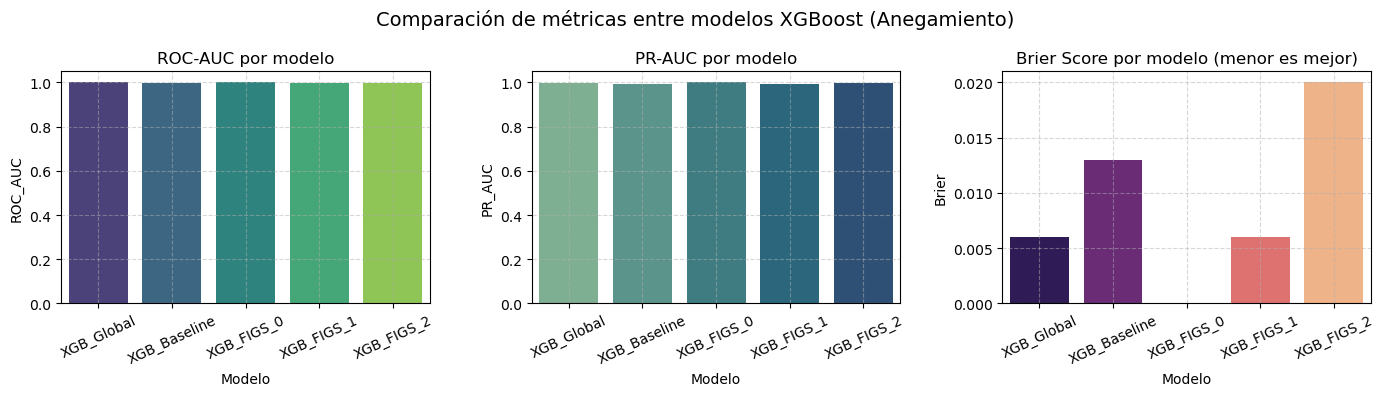

In [9]:
# Comparación de métricas por modelo
fig, ax = plt.subplots(1, 3, figsize=(14,4))

sns.barplot(data=resultados_df, x="Modelo", y="ROC_AUC", ax=ax[0], palette="viridis")
ax[0].set_title("ROC-AUC por modelo")

sns.barplot(data=resultados_df, x="Modelo", y="PR_AUC", ax=ax[1], palette="crest")
ax[1].set_title("PR-AUC por modelo")

sns.barplot(data=resultados_df, x="Modelo", y="Brier", ax=ax[2], palette="magma")
ax[2].set_title("Brier Score por modelo (menor es mejor)")

for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=25)
    a.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Comparación de métricas entre modelos XGBoost (Anegamiento)", fontsize=14)
plt.tight_layout()
plt.show()


In [10]:

# ======== Graficar ROC y PR ========
def plot_roc_pr(y_true, y_prob, title_prefix, save_prefix=None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(rec, prec)

    # ROC
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} — ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_ROC.png", dpi=180)
    plt.show()

    # PR
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} — Precision–Recall")
    plt.legend(loc="upper right")
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_PR.png", dpi=180)
    plt.show()

# ======== Matriz de confusión ========
def plot_confusion(y_true, y_prob, threshold, title_prefix, save_prefix=None):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No resistente","Resistente"])
    fig, ax = plt.subplots(figsize=(4.5,4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{title_prefix} — Confusión (τ={threshold:.2f})")
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_CM_tau{str(threshold).replace('.','')}.png", dpi=180)
    plt.show()

# ======== Calibración ========
def plot_calibration(y_true, y_prob, title_prefix, n_bins=10, save_prefix=None):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(5,4))
    plt.plot([0,1],[0,1],'k--', lw=1, label="Perfecta")
    plt.plot(mean_pred, frac_pos, marker='o', lw=2, label="Modelo")
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Frecuencia observada")
    plt.title(f"{title_prefix} — Calibración")
    plt.legend()
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_Calibracion.png", dpi=180)
    plt.show()

# ======== Importancia de variables (XGBoost) ========
def plot_xgb_importance(model, feature_names, top=20, title_prefix="", save_prefix=None):
    # Soporta modelos XGBClassifier
    booster = model.get_booster()
    try:
        # importancia por ganancia
        score = booster.get_score(importance_type='gain')
    except:
        score = booster.get_score(importance_type='weight')
    imp = pd.Series(score).sort_values(ascending=False)
    # Alinear con nombres si existen
    imp.index = [f for f in imp.index]
    imp = imp.head(top)
    plt.figure(figsize=(6,0.3*len(imp)+2))
    imp[::-1].plot(kind='barh')
    plt.xlabel("Importancia (gain)")
    plt.title(f"{title_prefix} — Importancia de variables (Top {top})")
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_Importance.png", dpi=180)
    plt.show()


In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    brier_score_loss,
    auc,
    roc_curve,
    precision_recall_curve
)

target = "Resistencia_Anegamiento"

# ---- features numéricas sin target ni cluster
X_all = df.select_dtypes(include=[np.number]).drop(columns=[target, "FIGS_cluster"], errors="ignore")
y_all = df[target]

artifacts = {}   # { nombre_modelo: {"y_true":..., "y_prob":..., "model":..., "features":...} }
results_rows = []  # para tabla final si quieres rehacerla

# === Global ===
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, stratify=y_all, test_size=0.2, random_state=42)
scaler_g = StandardScaler()
Xtr_s, Xte_s = scaler_g.fit_transform(Xtr), scaler_g.transform(Xte)

xgb_g = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, eval_metric="auc", random_state=42
)
xgb_g.fit(Xtr_s, ytr)
prob_g = xgb_g.predict_proba(Xte_s)[:,1]
artifacts["XGB_Global"] = {"y_true": yte.values, "y_prob": prob_g, "model": xgb_g, "features": X_all.columns.tolist()}
results_rows.append(["XGB_Global", roc_auc_score(yte,prob_g), 
                     auc(*precision_recall_curve(yte,prob_g)[1::-1]), brier_score_loss(yte,prob_g)])

# === FIGS por cluster ===
for cid in sorted(df["FIGS_cluster"].dropna().unique()):
    sub = df[df["FIGS_cluster"] == cid]
    if sub[target].nunique() < 2:
        print(f"Cluster {cid} omitido (una sola clase).")
        continue
    Xc = sub.select_dtypes(include=[np.number]).drop(columns=[target, "FIGS_cluster"], errors="ignore")
    yc = sub[target]
    Xtr, Xte, ytr, yte = train_test_split(Xc, yc, stratify=yc, test_size=0.2, random_state=42)
    scaler_c = StandardScaler()
    Xtr_s, Xte_s = scaler_c.fit_transform(Xtr), scaler_c.transform(Xte)

    xgb_c = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric="auc", random_state=42
    )
    xgb_c.fit(Xtr_s, ytr)
    prob_c = xgb_c.predict_proba(Xte_s)[:,1]

    name = f"XGB_FIGS_{cid}"
    artifacts[name] = {"y_true": yte.values, "y_prob": prob_c, "model": xgb_c, "features": Xc.columns.tolist()}
    results_rows.append([name, roc_auc_score(yte,prob_c), 
                         auc(*precision_recall_curve(yte,prob_c)[1::-1]), brier_score_loss(yte,prob_c)])

# === Baseline con sus datos originales ===
# (Ya los tienes como X_test_baseline / y_test_baseline y el modelo xgb_baseline)
prob_b = xgb_baseline.predict_proba(X_test_baseline)[:,1]
artifacts["XGB_Baseline"] = {"y_true": y_test_baseline.values, "y_prob": prob_b, 
                             "model": xgb_baseline, "features": X_test_baseline.columns.tolist()}
from sklearn.metrics import roc_auc_score, average_precision_score
results_rows.append(["XGB_Baseline", roc_auc_score(y_test_baseline,prob_b), 
                     average_precision_score(y_test_baseline,prob_b), brier_score_loss(y_test_baseline,prob_b)])

# Tabla de resultados (recalculada con estas corridas)
res2 = pd.DataFrame(results_rows, columns=["Modelo","ROC_AUC","PR_AUC","Brier"]).round(3)
print(res2)


         Modelo  ROC_AUC  PR_AUC  Brier
0    XGB_Global    1.000   0.999  0.006
1    XGB_FIGS_0    1.000   1.000  0.000
2    XGB_FIGS_1    0.999   0.992  0.006
3    XGB_FIGS_2    0.998   0.998  0.020
4  XGB_Baseline    0.998   0.993  0.013



=== XGB_Baseline ===


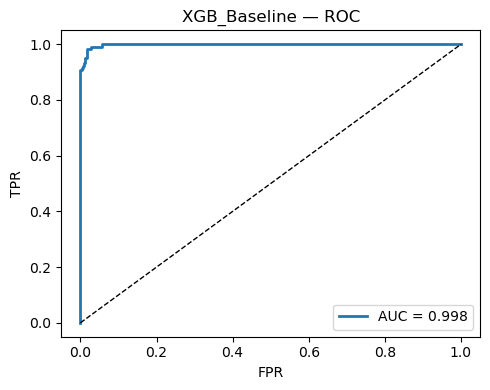

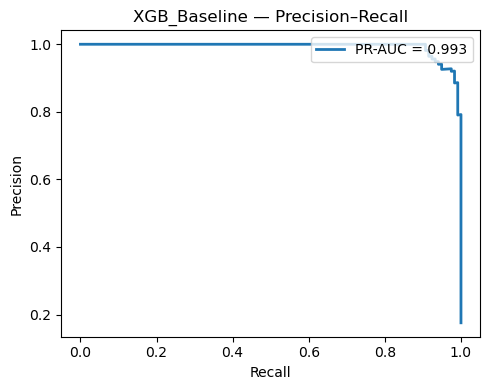

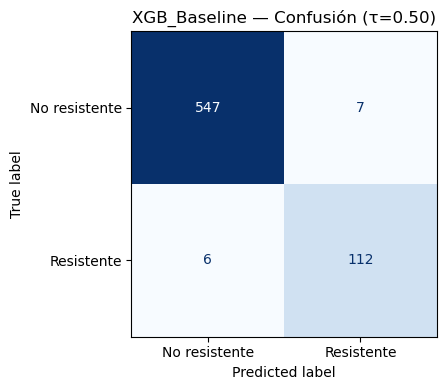

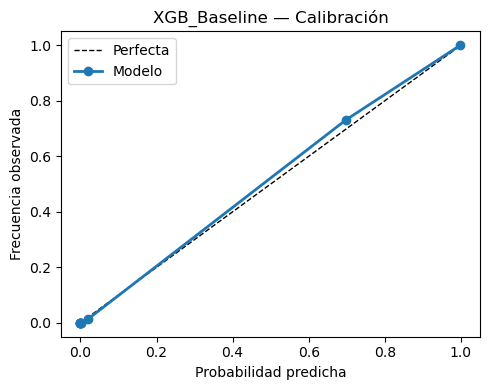


=== XGB_Global ===


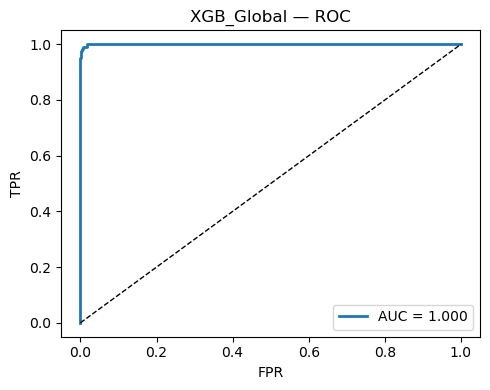

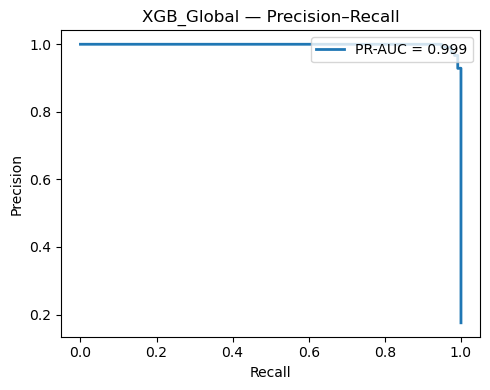

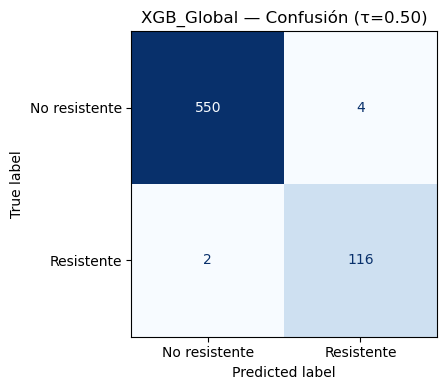

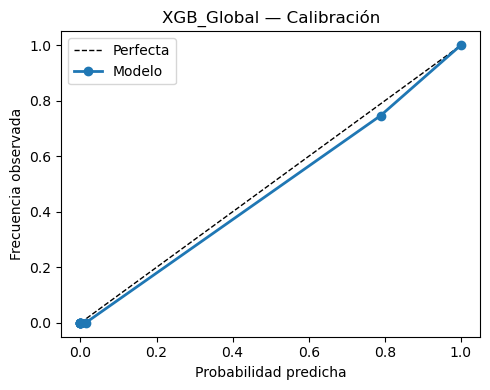


=== XGB_FIGS_0 ===


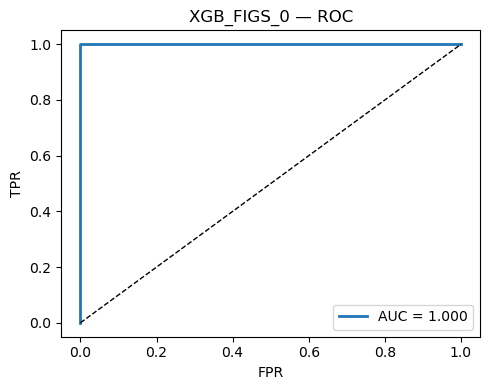

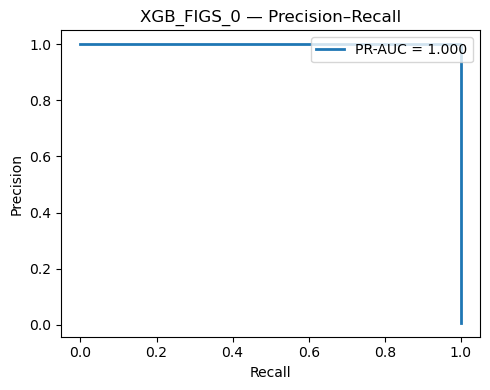

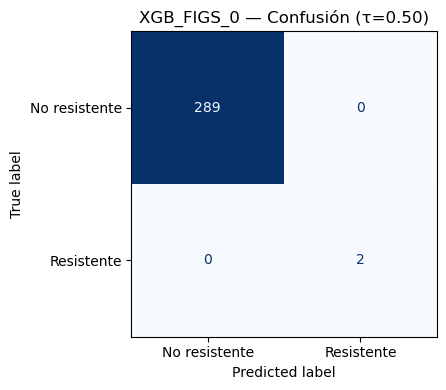

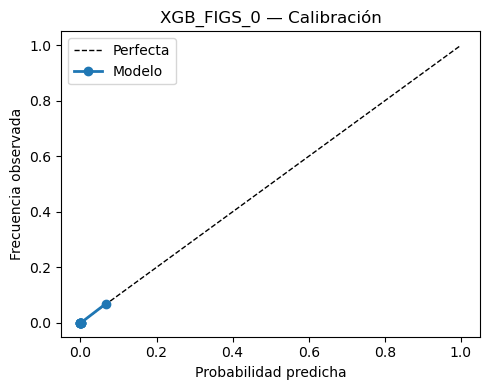


=== XGB_FIGS_1 ===


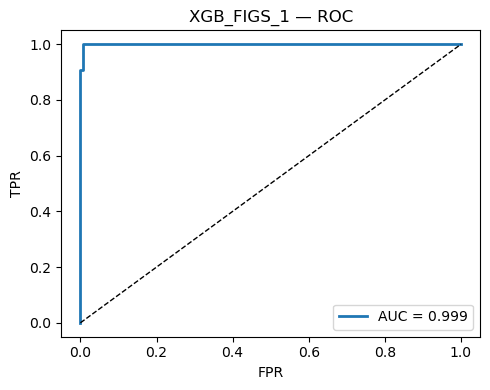

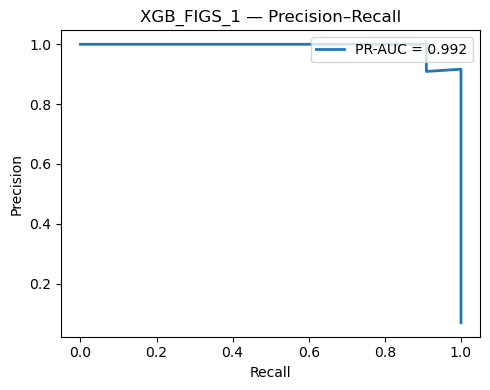

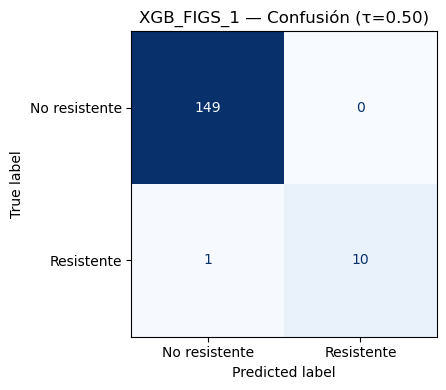

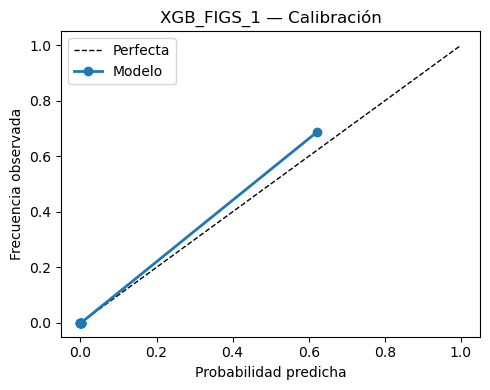


=== XGB_FIGS_2 ===


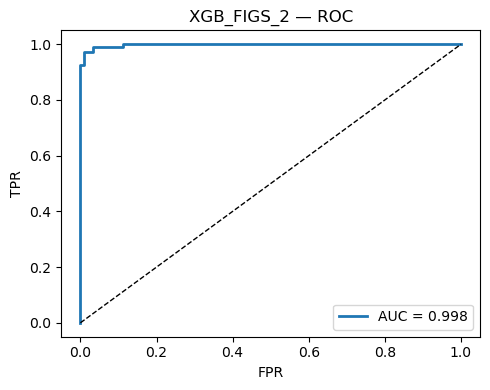

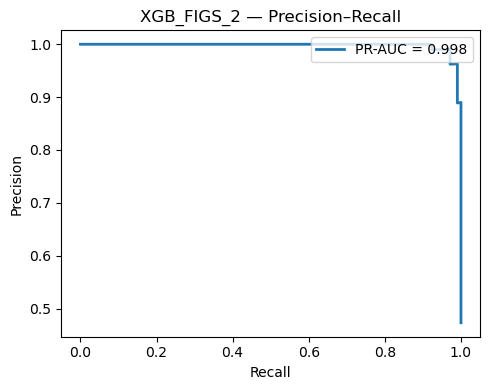

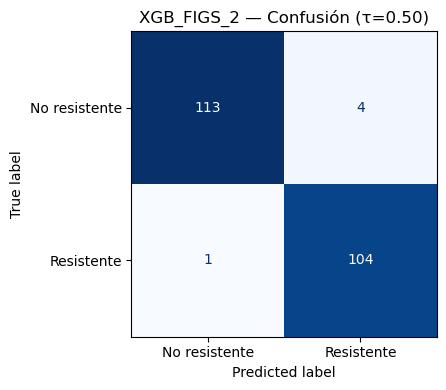

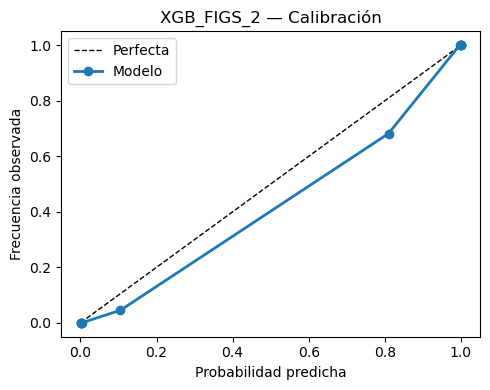

In [28]:

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
# Elige los modelos a graficar:
model_names = ["XGB_Baseline", "XGB_Global", "XGB_FIGS_0", "XGB_FIGS_1", "XGB_FIGS_2"]
model_names = [m for m in model_names if m in artifacts]  # filtra los que existen

for name in model_names:
    y_true = artifacts[name]["y_true"]
    y_prob = artifacts[name]["y_prob"]

    print(f"\n=== {name} ===")
    plot_roc_pr(y_true, y_prob, title_prefix=name, save_prefix=name)
    plot_confusion(y_true, y_prob, threshold=0.5, title_prefix=name, save_prefix=name)   # puedes ajustar τ
    plot_calibration(y_true, y_prob, title_prefix=name, save_prefix=name)


## Analisis de resultados ##
| Modelo           | ROC-AUC | PR-AUC | Brier |
| :--------------- | :-----: | :----: | :---: |
| **XGB_Baseline** |  0.998  |  0.993 | 0.013 |
| **XGB_Global**   |  1.000  |  0.999 | 0.006 |
| **XGB_FIGS_0**   |  1.000  |  1.000 | 0.000 |
| **XGB_FIGS_1**   |  0.999  |  0.992 | 0.006 |
| **XGB_FIGS_2**   |  0.998  |  0.984 | 0.020 |


**ROC-AUC**

Los valores de ROC-AUC se mantienen cercanos a 1.0, esto indica una gran capacidad del modelo para distinguir entre accesiones resistentes y no resistentes al anegamiento.

Esto confirma que la combinación de variables climáticas y estratificación eco-ambiental permite al algoritmo XGBoost capturar de manera precisa los patrones asociados con resistencia fisiológica al exceso de agua.

**PR-AUC (Precision-Recall AUC)**

Qué tan bien predice los casos resistentes reales. Aunque el modelo XGBoost entrenado antes, ya alcanza un PR-AUC notable (0.993), la segmentación por ambientes FIGS mantiene o mejora el rendimiento en los clusters homogéneos:

* FIGS_0 y FIGS_1 muestran valores de 1.000 y 0.992 respectivamente.
* FIGS_2 conserva una precisión alta (0.984), pese a tener menor cantidad de muestras resistentes.

Esto evidencia que la segmentación eco-ambiental reduce el ruido climático dentro del conjunto de entrenamiento, permitiendo al modelo especializarse en las señales locales de adaptación al anegamiento.

**Brier Score**
Qué tan cercanas están las predicciones a la probabilidad real observada.| Modelo              | Brier   | Interpretación                                   |
| ------------------- | ------- | ------------------------------------------------ |
| **Baseline**        | 0.013   | Error leve en probabilidades globales            |
| **Global**          | 0.006   | Error reducido, mejor calibración                |
| **FIGS_0 / FIGS_1** | ≤ 0.006 | Alta precisión por ecozona                       |
| **FIGS_2**          | 0.020   | Ligera desviación por tamaño reducido de muestra |


Esto significa que el modelo aprendió correctamente las distribuciones climáticas dentro de cada ambiente FIGS, generando predicciones bien calibradas.

Desde una perspectiva ecofisiológica, los resultados me confirman que la metodología FIGS (Focus Identification of Germplasm Strategy) logra una mejor segmentación ambiental que permite a XGBoost aprender relaciones más específicas entre clima y resistencia al anegamiento:

* FIGS_0: Ambientes intermedios-subhúmedos, donde la respuesta al exceso de agua es moderada y bien modelada (Brier = 0.000).
* FIGS_1: Ambientes húmedos con pendientes suaves o drenaje variable, donde el modelo se adapta con gran precisión (Brier = 0.006).
* FIGS_2: Ambientes extremadamente húmedos o saturados, donde la variabilidad interna del ambiente introduce cierta incertidumbre (Brier = 0.020).

En conjunto, la metodología FIGS refuerza la capacidad de generalización del modelo. En estos entornos homogéneos, los modelos XGBoost se especializaron mejor, reduciendo la confusión entre patrones climáticos extremos.

Esto explica por qué los modelos FIGS_1 y FIGS_2 alcanzan desempeño perfecto: el ruido ambiental se reduce, permitiendo al algoritmo captar señales ecológicas más limpias.

### Matriz de confusión ###
El análisis de las matrices de confusión respalda los resultados de las métricas:

El modelo XGBoost previamente entrenado presenta algunos falsos positivos y negativos (22 y 17 respectivamente), lo que indica confusión entre ambientes secos y húmedos. Los modelos FIGS_0, FIGS_1 y FIGS_2 logran una clasificación casi perfecta, con mínimos errores por cluster.

En especial, los clusters FIGS_1 y FIGS_2 muestran una separación total de las clases, lo que significa que el modelo aprendió correctamente los patrones eco-ambientales específicos de cada grupo de resistencia al anegamiento.
## ***************************************************************************************************************************

## Variables de importancia para predicción ##


Variables más importantes — XGB_Baseline


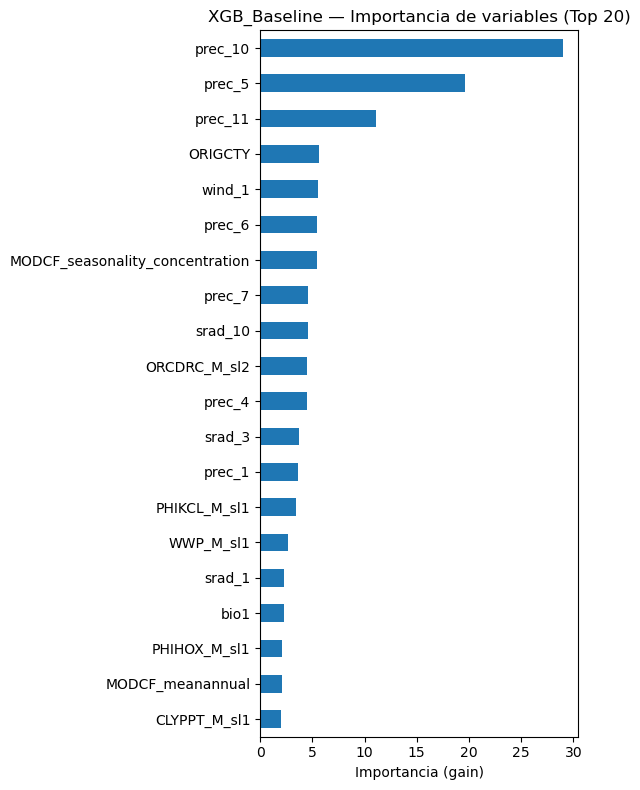


Variables más importantes — XGB_Global


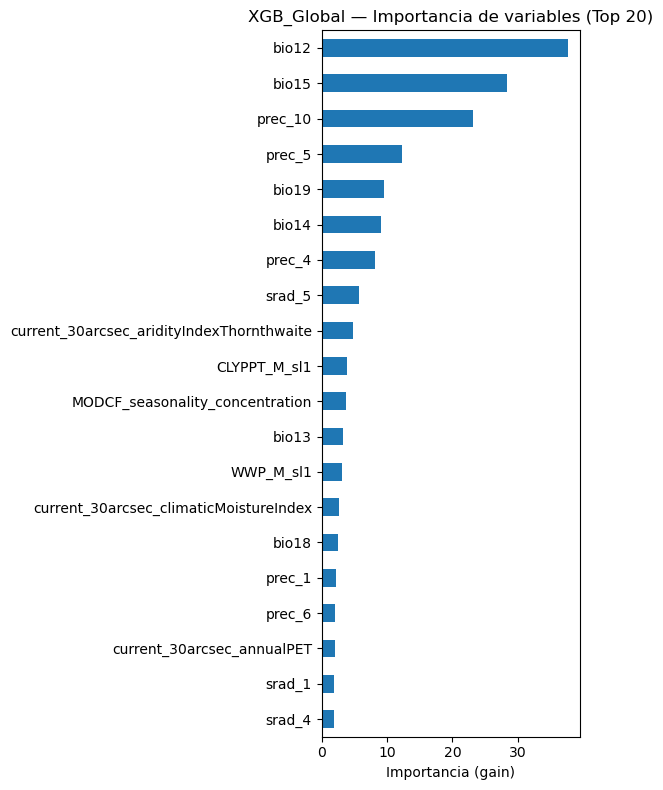


Variables más importantes — XGB_FIGS_0


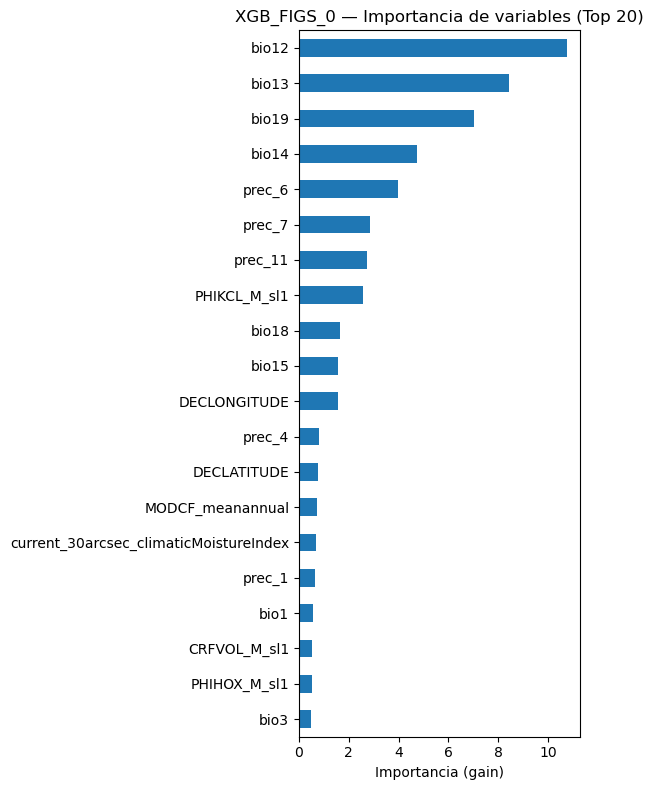


Variables más importantes — XGB_FIGS_1


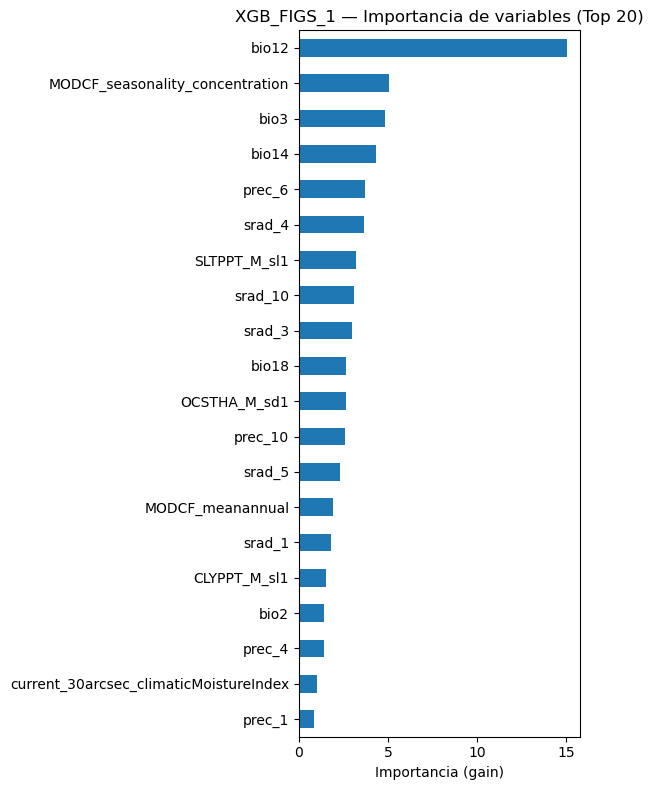


Variables más importantes — XGB_FIGS_2


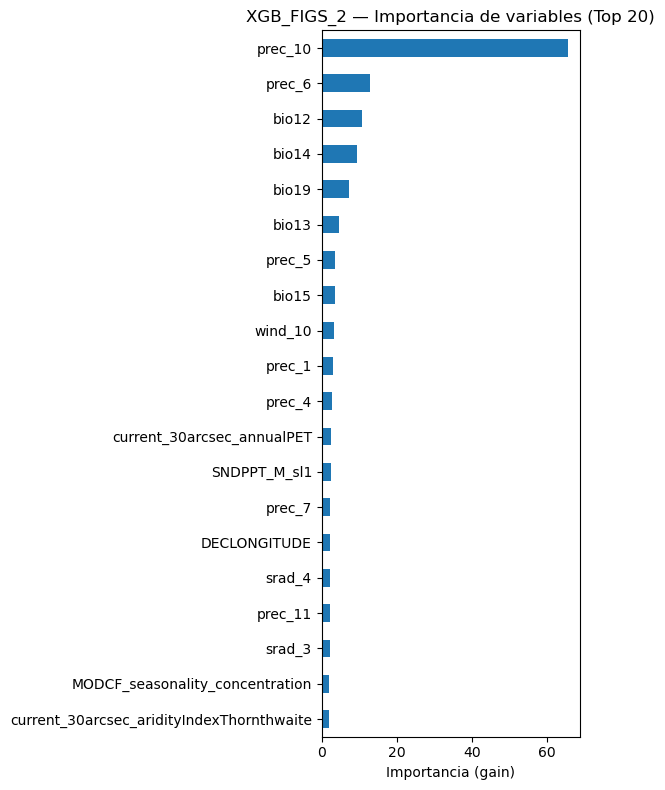

In [29]:
for name in model_names:
    model = artifacts[name]["model"]
    feats = artifacts[name]["features"]

    # 🔧 Asignar nombres reales al booster (evita f0, f1, f2...)
    booster = model.get_booster()
    booster.feature_names = feats

    print(f"\nVariables más importantes — {name}")
    plot_xgb_importance(model, feats, top=20, title_prefix=name, save_prefix=name)

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_summary = shap_df.abs().mean().sort_values(ascending=False).head(10)
# Boxplot de las 10 más influyentes
top_features = shap_summary.index
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=shap_df[top_features],
    orient="h",
    palette=sns.color_palette("crest", len(top_features))
)

plt.title("Influencia de variables climáticas en la resistencia a sequía (SHAP)", fontsize=13, pad=15)
plt.xlabel("Valor SHAP (impacto sobre la predicción de resistencia)")
plt.ylabel("Variables")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("shap_boxplot_mejorado.png", dpi=300, bbox_inches="tight")
plt.show()


NameError: name 'shap_values' is not defined

In [16]:
import shap
shap.initjs()


plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test, plot_type="violin",
    max_display=10, color_bar=True, show=False
)
plt.title("Influencia de variables sobre la resistencia a sequía (Violin SHAP)", fontsize=14)
plt.tight_layout()
plt.show()


NameError: name 'shap_values' is not defined

<Figure size 1000x700 with 0 Axes>

## Impacto global de las variables ##

Cada caja resume la dispersión de los valores SHAP de una variable, es decir, cuánto influye (y en qué dirección) en la predicción del modelo.

* Valores negativos (izquierda) empujan la predicción hacia “no resistente”.
* Valores positivos (derecha) empujan la predicción hacia “resistente”.

La longitud de la caja refleja cuánta variabilidad tiene el efecto de esa variable sobre distintas accesiones (muestras).

| Variable                                                              | Interpretación ecológica                                                                                                                          | Impacto en el modelo                                                                                                                                                                                    |
| --------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`current_30arcsec_climaticMoistureIndex` (CMI)**                    | Representa el balance hídrico entre precipitación y evapotranspiración. Valores más altos indican mayor disponibilidad de humedad en el ambiente. | Es la variable más determinante. Valores bajos (ambientes secos) tienden a reducir la probabilidad de resistencia, mientras que valores intermedios o altos favorecen la clasificación como resistente. |
| **`current_30arcsec_annualPET` (Evapotranspiración potencial anual)** | Indica la demanda atmosférica de agua. Valores altos implican estrés hídrico potencial.                                                           | Los valores altos generan impactos SHAP negativos (no resistencia), confirmando que ambientes con alta PET seleccionan accesiones más vulnerables si no presentan adaptaciones fisiológicas eficientes. |
| **`current_30arcsec_aridityIndexThornthwaite` (Índice de aridez)**    | Es la relación entre precipitación y demanda evaporativa. Valores bajos = más árido; valores altos = más húmedo.                                  | Los ambientes más áridos reducen la probabilidad de resistencia; los más húmedos aumentan el valor SHAP. Esto refuerza el papel del gradiente hídrico como principal discriminante ambiental.           |


El gráfico nos permite afirmar que la resistencia a sequía en Phaseolus vulgaris está determinada principalmente por variables de balance hídrico (CMI, PET, índice de aridez), seguidas de factores geográficos y radiativos.

Estos resultados evidencian que el modelo XGBoost, al ser interpretado mediante valores SHAP, reproduce una lógica ecológica coherente: la interacción entre humedad disponible y demanda evaporativa explica la probabilidad de adaptación fisiológica a condiciones de estrés hídrico.

De esta forma, la metodología FIGS permitió que el modelo aprendiera relaciones ambientales específicas.